In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np

import psycopg2
import os
from dotenv import load_dotenv

load_dotenv()

DATABASE_URL = os.getenv("DATABASE_URL")

In [4]:
conn = psycopg2.connect(DATABASE_URL)
cursor = conn.cursor()
query = '''SELECT * FROM ads_cleaned '''
cursor.execute(query)
rows = cursor.fetchall()

columns = [description[0] for description in cursor.description]

df = pd.DataFrame(data=rows, columns=columns)

In [5]:
df.head()

,hash_id,title,img_url,link,neighbourhood,type_of_estate,total_price_eur,price_m2_eur,price_m2_bgn,size_m2,nr_of_rooms,description,floor,akt16,energy_class,potreblenie,broker_commision,additional_notes,extras
0,191cff973bff3518de40c8019f6c3d5fea7174c95837aa...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256545...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.00,2263.00,4426.32,57.00,2.0,"Двустаен апартамент с площ 57,01м2 /ЗП 48,86м2...",4.0,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,None
1,9eb41908d4e61b7008f29eb1688015f63ff3cdf229084b...,"Имот - продава Двустаен апартамент, в София, М...",https://www.imoti.net/web/files/obiavi/6256546...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,128991.00,2263.00,4426.32,57.00,2.0,"Двустаен апартамент с площ 57,01м2 /ЗП 48,86м2...",4.0,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,None
2,dbc5d9466f8d880697f9fee292fe7c5fc84663ec10bcd4...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6262276...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,129000.00,2580.00,5046.04,50.00,2.0,Компания `ЕКС` представя на Вашето внимание фу...,5.0,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,Обзаведен; ТЕЦ; Асансьор
3,6833ef4bed6c98041e1c7433fc60698103a43595c45950...,"Имот - продава Двустаен апартамент, в София, В...",https://www.imoti.net/web/files/obiavi/6246165...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Връбница 2,жилище,128984.00,2804.00,5484.83,46.00,2.0,Реф. 013417 Агенция за недвижими имоти BAS P...,5.0,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,Обзаведен
4,65707b6e4a05c4b88ad12e0779c1fc35bd125f66133bc6...,"Имот - продава Едностаен апартамент, в София, ...",https://www.imoti.net/web/files/obiavi/6248616...,https://www.imoti.net/bg/obiava/prodava/sofia/...,Малинова Долина,жилище,133014.00,3167.00,6193.46,42.00,1.0,Референтен номер: 2109493 Революшън Естейт пре...,3.0,True,N/A,N/A,True,Посочената цена не включва местни данъци и такси.,None


We have to clear the land-only ads. They include "Земеделски имот" in their titles

In [6]:
exclude_terms = ["Земеделски имот", "Сграда", "Склад", "Промишлен имот"]
pattern = "|".join(exclude_terms)

print(f"Rows before removal of land-only ads: {len(df)}")
df = df[~df["title"].str.contains(pattern, na=False)]
print(f"Rows after removal of land-only ads: {len(df)}")

Rows before removal of land-only ads: 5879
Rows after removal of land-only ads: 5818


In [5]:
df.to_csv("../data/ads_appartments_cleaned.csv", index=False)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5818 entries, 0 to 5878
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hash_id           5818 non-null   object 
 1   title             5818 non-null   object 
 2   img_url           5815 non-null   object 
 3   link              5818 non-null   object 
 4   neighbourhood     5699 non-null   object 
 5   type_of_estate    5818 non-null   object 
 6   total_price_eur   5780 non-null   object 
 7   price_m2_eur      5780 non-null   object 
 8   price_m2_bgn      5791 non-null   object 
 9   size_m2           5780 non-null   object 
 10  nr_of_rooms       4735 non-null   float64
 11  description       5818 non-null   object 
 12  floor             5030 non-null   float64
 13  akt16             4985 non-null   object 
 14  energy_class      5235 non-null   object 
 15  potreblenie       5235 non-null   object 
 16  broker_commision  5762 non-null   object 
 17  

In [9]:
df['total_price_eur'] = pd.to_numeric(df['total_price_eur'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5818 entries, 0 to 5878
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hash_id           5818 non-null   object 
 1   title             5818 non-null   object 
 2   img_url           5815 non-null   object 
 3   link              5818 non-null   object 
 4   neighbourhood     5699 non-null   object 
 5   type_of_estate    5818 non-null   object 
 6   total_price_eur   5780 non-null   float64
 7   price_m2_eur      5780 non-null   object 
 8   price_m2_bgn      5791 non-null   object 
 9   size_m2           5780 non-null   object 
 10  nr_of_rooms       4735 non-null   float64
 11  description       5818 non-null   object 
 12  floor             5030 non-null   float64
 13  akt16             4985 non-null   object 
 14  energy_class      5235 non-null   object 
 15  potreblenie       5235 non-null   object 
 16  broker_commision  5762 non-null   object 
 17  

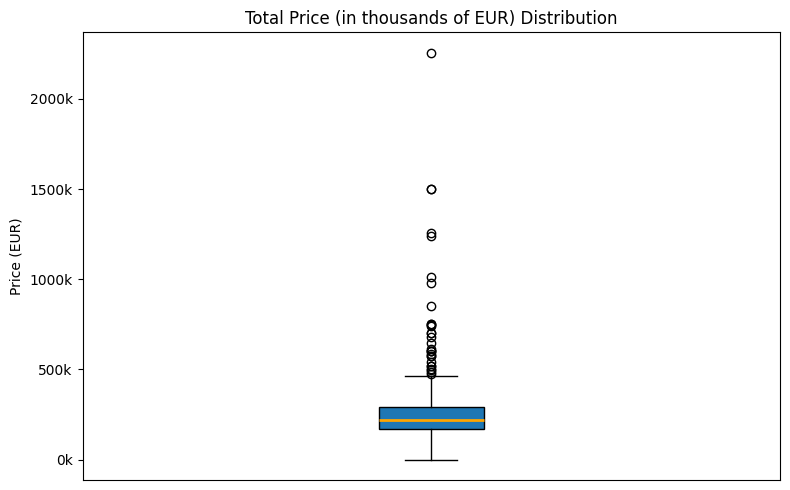

In [10]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Total Price (in thousands of EUR) Distribution')
ax.set_ylabel('Price (EUR)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax.set_xticks([])
plt.tight_layout()
plt.show()


From the looks of it we have a right-skewed distribution. The reason might be the luxury/expensive appartments which pull the tail to the right. There are also some outliers in the lower/left-tail and those are most likely the cheaper listings which are 'under-market' value. <br>
Let's apply a log transform to see if it looks better. <br> Note: Log transformation pulls the right tail to the left which makes it suitable when we have right-skewed distributions because the larger the difference becomes b/w data points the log converts it to an additive function hence, differences become smaller in that log dimension.

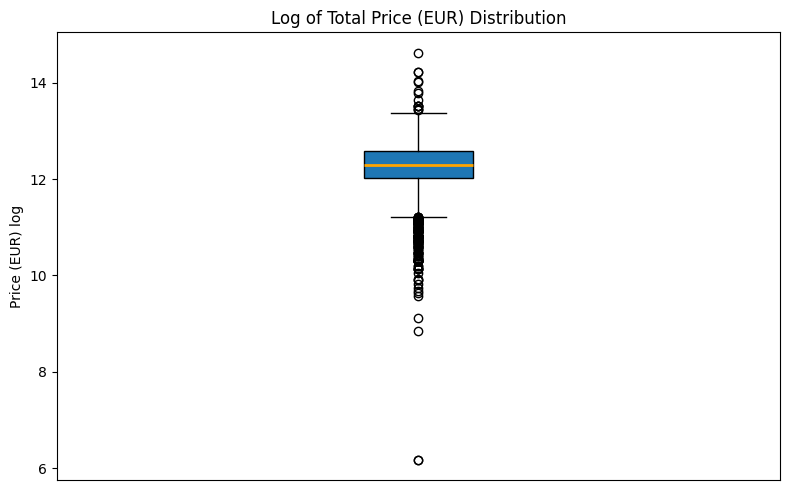

In [11]:
import numpy as np
df["log_total_price_eur"] = np.log(df["total_price_eur"])

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df['log_total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Log of Total Price (EUR) Distribution')
ax.set_ylabel('Price (EUR) log')
ax.set_xticks([])
plt.tight_layout()
plt.show()

The log transformation compressed the right tail and managed to make the distribution look closer to a normal one. We see better now that there are also outliers on the left tail which could be undervalued listings or could be land-only ones or could be wrong ones (e.g. missing a digit). <br><br>
The standard approach would be to use the IQR rule to capture the values below & above Q1 - 1.5xIQR & Q3 + 1.5xIQR (or even use 3x if we don't want to be too aggresive with the cut). After that we can either a) drop those values or b) winsorise them - make them equal to the lower & upper bonds. All values which are < lower and > upper will be converted to the corresponding values. <br> <br>
**The practical trade-off vs dropping** <br>
Dropping says "this data point is so extreme it's probably wrong or unlearnable — pretend it doesn't exist." Winsorising says "this data point is extreme but I believe the row's other features are still useful — just don't let the price value itself have undue influence."

37 outliers (0.6% of data)


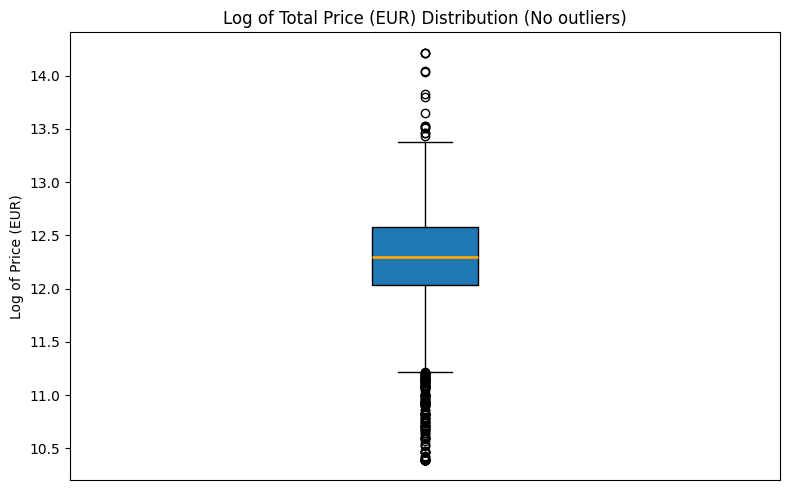

In [12]:
Q1 = df["log_total_price_eur"].quantile(0.25)
Q3 = df["log_total_price_eur"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 3 * IQR
upper = Q3 + 3 * IQR

# Inspect before dropping
outliers = df[(df["log_total_price_eur"] < lower) | (df["log_total_price_eur"] > upper)]
print(f"{len(outliers)} outliers ({len(outliers)/len(df):.1%} of data)")

df_no_outiers = df.copy()

# Option A: drop
# df_clean = df[(df["log_total_price_eur"] >= lower) & (df["log_total_price_eur"] <= upper)]

# Option B: winsorise (safer for tree models)
df_no_outiers["log_total_price_eur"] = df_no_outiers["log_total_price_eur"].clip(lower, upper)

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(df_no_outiers['log_total_price_eur'].dropna(), vert=True, patch_artist=True,
        #    boxprops=dict(facecolor='steelblue', color='navy'),
           medianprops=dict(color='orange', linewidth=2))
ax.set_title('Log of Total Price (EUR) Distribution (No outliers)')
ax.set_ylabel('Log of Price (EUR)')
ax.set_xticks([])
plt.tight_layout()
plt.show()

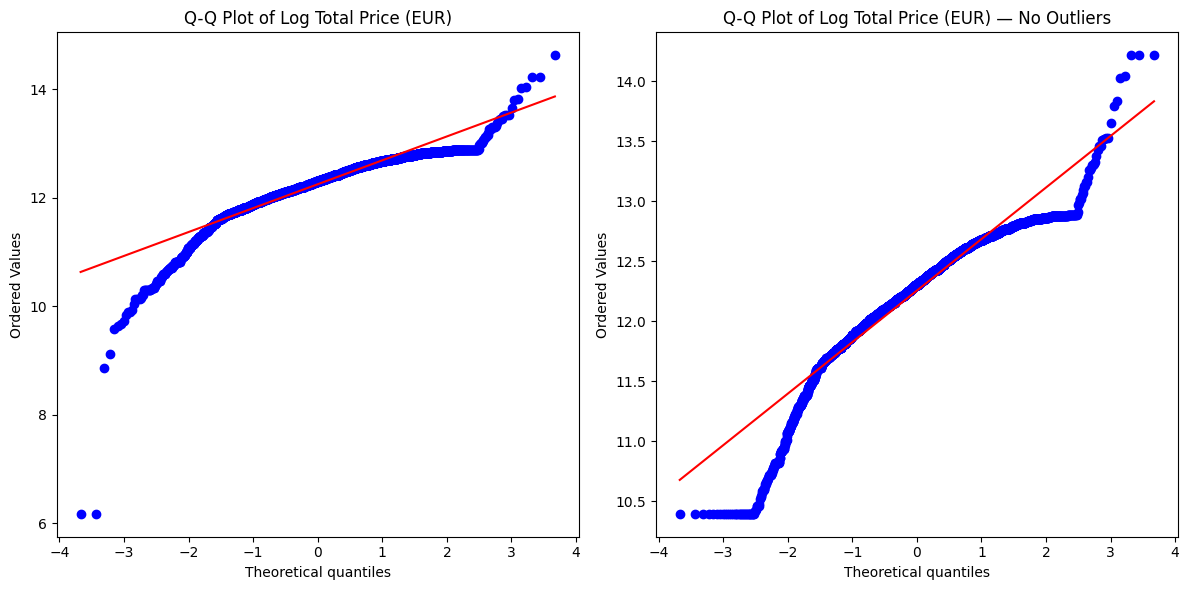

In [13]:
from scipy import stats

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

stats.probplot(df['log_total_price_eur'].dropna(), dist='norm', plot=ax[0])
ax[0].set_title('Q-Q Plot of Log Total Price (EUR)')

stats.probplot(df_no_outiers['log_total_price_eur'].dropna(), dist='norm', plot=ax[1])
ax[1].set_title('Q-Q Plot of Log Total Price (EUR) — No Outliers')

plt.tight_layout()
plt.show()


## Q-Q Plot Analysis — Log Total Price (EUR), No Outliers

**Central region (theoretical quantiles −1 to +2)**
Points track the reference line closely, meaning the bulk of the distribution is well approximated by a normal distribution.

**Left tail (quantiles < −2)**
Points drop below the line and flatten into a horizontal shelf — a direct artefact of the lower winsorisation clip. Many observations were clamped to the same minimum value, causing them to stack. This also hints at a real-world price floor in the data (many listings clustered at a round minimum price).

**Right tail (quantiles > 2.5)**
Two distinct features appear:
1. **Near-vertical stack crossing the line from below to above** — just before the final plateau, a cluster of points rises steeply and overshoots the reference line. This means the actual values there barely change while the theoretical quantiles spread them out, i.e. the data is **more densely packed** at that range than a normal distribution predicts. In real-estate terms this likely reflects a concentration of similarly-priced premium listings (e.g. many properties priced around a round high-end value) creating a local mini-mode in the upper tail — more "traffic" than a normal would expect.
2. **Final horizontal plateau** — the winsorisation clip. All values originally above `upper` were set to exactly `upper`, so they share the same y-value and spread across several theoretical quantiles, producing a flat shelf at the top.

**Overall verdict**
The log-price distribution is approximately normal in the centre but its upper tail has two real features: a genuine **local clustering of high-end listings** (the near-vertical crossing) and a **winsorisation artefact** (the final plateau). For tree-based models this is generally acceptable. For linear models, consider:
- Filtering below a credible minimum price to address the left-tail clump.
- Investigating the premium cluster — it may warrant a separate indicator feature or a stricter upper clip.


Here's what the Q-Q plot reveals:

Central region (theoretical quantiles -1 to +2)
The points track the reference line closely — the bulk of the distribution is well approximated by a normal.

Left tail (quantiles < -2)
The points drop below the line and flatten into a horizontal band around log-price ~10.75. This is the lower winsorisation clip in action: many observations were clamped to the same value, so they stack up as a flat shelf. It also suggests a real-world price floor in the data (many cheap listings at a round price).

Right tail (quantiles > 2.5)
Two issues:

A plateau at ~12.6 — the upper winsorisation boundary. Values above the clip are stacked there.
Points then jump sharply to ~13.6–13.7, sitting well above the line. These are values that escaped the 3×IQR clip (or are a distinct cluster of luxury/outlier listings). The right tail is heavier than normal.
Overall verdict
The log-price distribution is close to normal in the centre but shows leptokurtic (heavy) tails on both sides, with additional artefacts from the winsorisation. For a regression model this is acceptable, but worth noting:

The left-tail clump could be addressed by filtering below a minimum credible price.
The right-tail cluster above the clip may need a stricter upper bound or separate treatment if you plan to use a linear model that assumes normality of residuals.

In [58]:
skewness = df_no_outiers['log_total_price_eur'].skew()
kurt = df_no_outiers['log_total_price_eur'].kurt()  # excess kurtosis (Fisher definition)

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis (excess): {kurt:.4f}")

Skewness : -0.4331
Kurtosis (excess): 1.5244


## Skewness & Kurtosis Analysis — Log Total Price (EUR), No Outliers

| Metric | Value | Benchmark (normal) |
|---|---|---|
| Skewness | −0.433 | 0 |
| Excess Kurtosis | 1.52 | 0 |

### Skewness: −0.433
A value of **−0.43** indicates mild **negative (left) skew**. This means the left tail is slightly heavier than the right — the distribution has more observations bunched toward higher log-prices, with a longer drag to the lower end. This is consistent with the Q-Q plot's left-tail shelf caused by the lower winsorisation clip. In practical terms, there are relatively few very cheap listings but they pull the mean down below the median.

A rule of thumb: |skewness| < 0.5 is considered roughly symmetric, 0.5–1.0 is moderate skew. At −0.43 the distribution is **moderately skewed** but not severely so.

### Excess Kurtosis: 1.52
An excess kurtosis of **1.52** (well above 0) indicates a **leptokurtic** distribution — the tails are heavier and the peak is sharper than a normal distribution. This aligns with the Q-Q plot showing points diverging from the line in both tails. The elevated kurtosis is partly a winsorisation artefact (stacking values at the clip boundaries creates heavier tails) and partly a genuine property of real-estate prices, which tend to have a dense central mass and occasional extreme values.

### Implications for Modelling
- **Tree-based models** (Random Forest, XGBoost) are robust to both skew and heavy tails — no further transformation needed.
- **Linear / regularised regression**: the moderate skew and excess kurtosis suggest residuals may deviate from normality. Consider keeping the log transform and potentially clipping at tighter bounds (e.g. 2×IQR) to reduce the kurtosis effect.


In [14]:
cols_to_drop = ["hash_id", "link", "img_url", "description", "extras", "title", "neighbourhood", 
                "type_of_estate", "energy_class", "additional_notes"]
corr = df.drop(columns=cols_to_drop).corr()["log_total_price_eur"].drop(["log_total_price_eur", "total_price_eur", "price_m2_bgn", "price_m2_eur"]).sort_values()
corr.plot(kind="barh", figsize=(8, 6), title="Correlation with log_price")

ValueError: could not convert string to float: 'N/A'

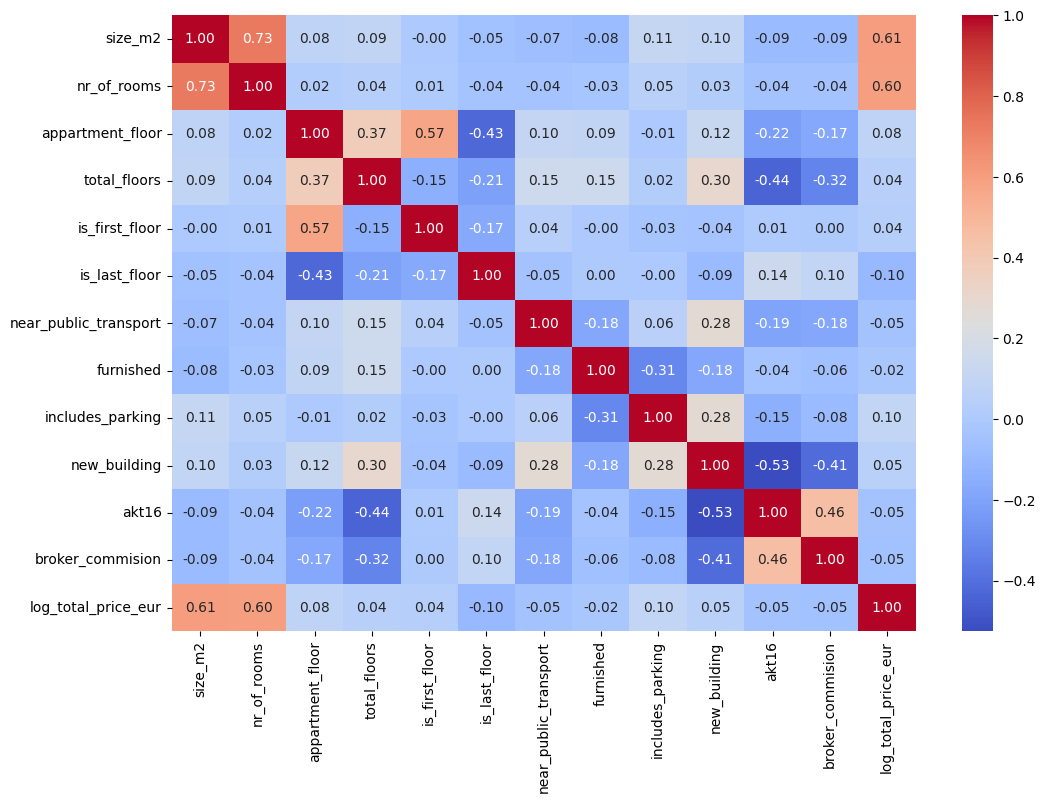

In [60]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(df.drop(columns=["total_price_eur", "price_m2_bgn", "price_m2_eur", "potreblenie"]).select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.show()

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = df.drop(columns=["total_price_eur", "price_m2_bgn", "price_m2_eur", "potreblenie", "log_total_price_eur"]).select_dtypes("number").dropna()

vif_df = pd.DataFrame({
    "feature": numeric_cols.columns,
    "VIF": [variance_inflation_factor(numeric_cols.values, i) for i in range(numeric_cols.shape[1])]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))
print("\n--- Correlation with log_total_price_eur ---")
print(df[numeric_cols.columns.tolist() + ["log_total_price_eur"]].corr()["log_total_price_eur"].drop("log_total_price_eur").sort_values(key=abs, ascending=False))

              feature       VIF
          nr_of_rooms 30.319541
              size_m2 23.507818
       is_first_floor 11.627333
     broker_commision 11.258736
                akt16  9.229777
     appartment_floor  8.554322
            furnished  5.807660
         total_floors  2.550826
         new_building  1.928795
near_public_transport  1.908332
        is_last_floor  1.485273
     includes_parking  1.454698

--- Correlation with log_total_price_eur ---
size_m2                  0.606211
nr_of_rooms              0.599855
is_last_floor           -0.096056
includes_parking         0.095108
appartment_floor         0.080013
broker_commision        -0.051925
new_building             0.050740
akt16                   -0.046505
near_public_transport   -0.045052
total_floors             0.044988
is_first_floor           0.038752
furnished               -0.016145
Name: log_total_price_eur, dtype: float64


Variance Inflation Factor (VIF) measures multicollinearity by quantifying how much the variance of an estimated regression coefficient is increased due to collinearity. It is computed for each predictor (X_i) by running a regression against all other predictors

## Correlation Heatmap & Multicollinearity Analysis

### Correlation with `log_total_price_eur`

| Feature | r | Interpretation |
|---|---|---|
| `nr_of_rooms` | **+0.60** | Moderate — the dominant linear predictor |
| `includes_parking` | +0.09 | Weak linear |
| `appartment_floor` | +0.08 | Weak linear |
| `is_last_floor` | −0.08 | Weak linear |
| `new_building`, `akt16`, etc. | < 0.07 | Near-zero linear |
| `size_m2` | −0.02 | Practically zero linear |

**Is this a problem?** No — and here is why.

Pearson correlation only captures *linear* relationships. Most real-estate features have inherently non-linear relationships with price:
- `new_building` and `akt16` are binary flags — their effect is a step, not a slope. Pearson r will always understate this.
- `appartment_floor` likely has a U-shaped or threshold effect (ground floor = discount, top floor = premium), which flattens to near-zero in a linear measure.
- `furnished` and `includes_parking` add a flat premium regardless of base price, again non-linear on the log scale.

**For tree-based models (Random Forest, XGBoost)** this is a non-issue — they discover splits and interactions automatically. A feature with r = 0.05 can still substantially reduce prediction error if it creates a clean binary split. **For linear / regularised regression**, these features will contribute less unless you engineer interaction terms (e.g. `appartment_floor × total_floors`).

---

### Multicollinearity — VIF Results

| Feature | VIF | Verdict |
|---|---|---|
| `nr_of_rooms` | **30.3** | Severe — strongly collinear with `size_m2` |
| `size_m2` | **23.5** | Severe — strongly collinear with `nr_of_rooms` |
| `is_first_floor` | **11.6** | High — essentially a binary derived from `appartment_floor` |
| `broker_commision` | **11.3** | High — investigate what drives this |
| `akt16` | 9.2 | Moderate-high |
| `appartment_floor` | 8.6 | Moderate — partially explained by `is_first_floor` + `total_floors` |
| `furnished` | 5.8 | Moderate |
| Remaining features | < 3 | Acceptable |

#### Pair 1 — `nr_of_rooms` vs `size_m2` (the one you noticed)

These two features encode largely the same concept (apartment size), hence VIF > 20 for both. The asymmetry with the target is striking: `nr_of_rooms` has r = +0.60 while `size_m2` has r = −0.02. A likely explanation is that in this market room count is a stronger pricing signal than raw floor area — a 3-room flat at 60 m² will command a similar price to a 3-room flat at 80 m² because buyers price by room count. It is worth investigating both separately.

**Recommendations:**
- **Preferred option:** Create a `avg_room_size_m2 = size_m2 / nr_of_rooms` ratio feature. This captures apartment *efficiency/luxury density* (a compact studio vs a spacious flat with the same room count), and removes the redundancy between the two raw features.
- **Simple fallback:** Drop `size_m2` and keep `nr_of_rooms` (it carries all the linear signal). For tree models you can keep both but the gain is minimal.

#### Pair 2 — `is_first_floor` vs `appartment_floor`

`is_first_floor` is effectively a binarisation of `appartment_floor == 1`, so the information is almost entirely redundant. Drop `is_first_floor` and keep `appartment_floor`. If you want to retain the first-floor discount signal explicitly, create `relative_floor = appartment_floor / total_floors` instead — it captures position within the building continuously and absorbs both features.

#### `broker_commision` (VIF = 11.3)

A brokerage fee indicator should not be strongly collinear with property features — worth checking whether it is accidentally correlated with listing source or property tier. If it is, it may be a data-leakage risk (the commission might be set *because* of the price) rather than a genuine causal predictor. Treat with caution.

---

### Summary of Recommended Actions

1. **Investigate `nr_of_rooms` vs `size_m2` separately** (scatter plots against `log_total_price_eur`, compare R²). Then either drop `size_m2` or replace both with `avg_room_size_m2 = size_m2 / nr_of_rooms`.
2. **Drop `is_first_floor`**; create `relative_floor = appartment_floor / total_floors` to capture floor position.
3. **Audit `broker_commision`** for potential data leakage.
4. **Keep all other features for tree models** — low Pearson r ≠ low predictive value when the model can learn non-linear splits.

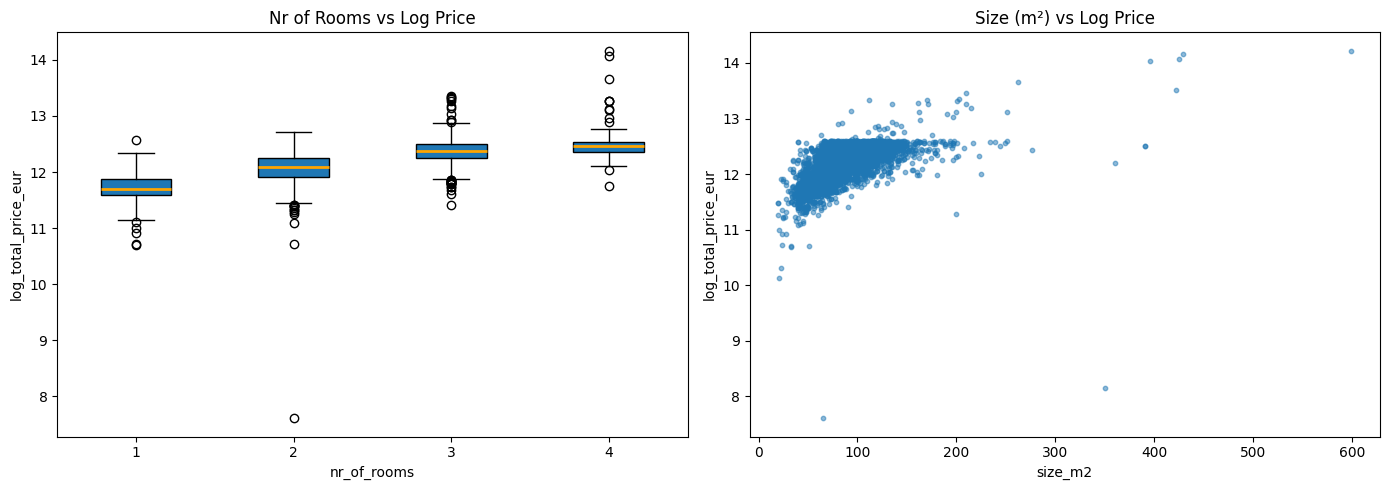

In [72]:
fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(14, 5))

# Boxplot: group log_price by each integer room count
room_groups = [grp["log_total_price_eur"].dropna().values
               for _, grp in df.groupby("nr_of_rooms")]
room_labels = sorted(df["nr_of_rooms"].dropna().unique().astype(int))
axes[0].boxplot(room_groups, tick_labels=room_labels, patch_artist=True,
                medianprops=dict(color="orange", linewidth=2))
axes[0].set_xlabel("nr_of_rooms")
axes[0].set_ylabel("log_total_price_eur")
axes[0].set_title("Nr of Rooms vs Log Price")

axes[1].scatter(df["size_m2"], df["log_total_price_eur"], alpha=0.5, s=10)
axes[1].set_xlabel("size_m2")
axes[1].set_ylabel("log_total_price_eur")
axes[1].set_title("Size (m²) vs Log Price")

plt.tight_layout()
plt.show()

In [77]:
df.isna().sum()

hash_id                     0
title                       0
img_url                     0
link                        0
neighbourhood              91
type_of_estate              0
total_price_eur            86
price_m2_eur               80
price_m2_bgn               80
size_m2                    86
nr_of_rooms               218
description               273
appartment_floor          111
total_floors                0
is_first_floor            111
is_last_floor               0
near_public_transport       0
furnished                   0
includes_parking            0
new_building                0
akt16                     454
energy_class             5406
potreblenie              5429
broker_commision           98
additional_notes           80
extras                      7
log_total_price_eur        86
dtype: int64

We can remove potreblenie & energy_class cols as they are empty

Detected binary columns: ['total_floors', 'is_last_floor', 'near_public_transport', 'furnished', 'includes_parking', 'new_building', 'akt16', 'potreblenie', 'broker_commision']


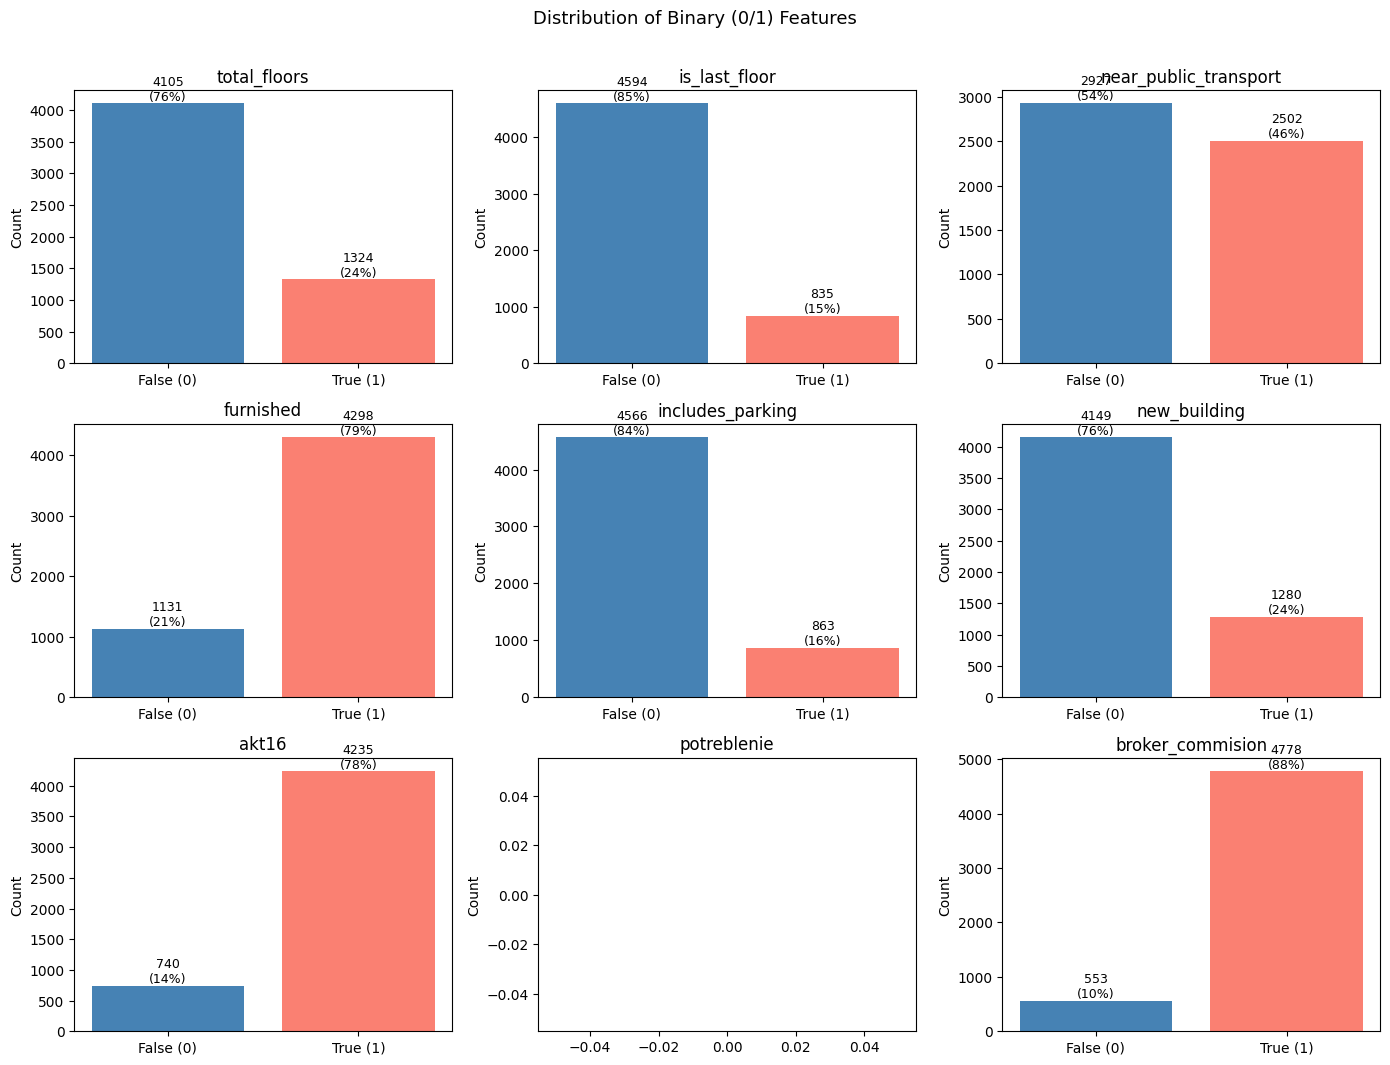

In [87]:
num_cols = df.select_dtypes("number").columns
bool_cols = [c for c in num_cols if df[c].dropna().isin([0, 1]).all()]
print("Detected binary columns:", bool_cols)

n = len(bool_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(bool_cols):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.map({1: "True (1)", 0: "False (0)"}), counts.values, color=["steelblue", "salmon"])
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")
    for bar, v in zip(axes[i].patches, counts.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                     f"{v}\n({v/len(df):.0%})", ha="center", va="bottom", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Binary (0/1) Features", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── SMALLINT column cleanup ────────────────────────────────────────────────
# nr_of_rooms, appartment_floor, total_floors are SMALLINT in the DB.
# pandas reads them as float64 (due to NaN rows). Cast to nullable Int16
# so the saved CSV holds integers (not 1.0) and migration sends the right type.

smallint_cols = ["nr_of_rooms", "appartment_floor", "total_floors"]
for col in smallint_cols:
    if col in df.columns:
        df[col] = df[col].astype("Int16")   # nullable int — keeps NaN as <NA>

print("Smallint columns after cast:")
print(df[smallint_cols].dtypes)
print(df[smallint_cols].head(3))


In [ ]:
df_cleaned = df.drop(
    labels=["type_of_estate", "potreblenie", "energy_class", "extras",
            "additional_notes", "description", "title", "link", "img_url"],
    axis=1
)

df_cleaned.to_csv("../data/ads_appartments_cleaned.csv", index=False)
print(f"Saved {len(df_cleaned)} rows → data/ads_appartments_cleaned.csv")
print(df_cleaned.dtypes)
